In [84]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

import simulate_data as sim
reload(sim)

import elbo
reload(elbo)

import gibbs 
reload(gibbs)

<module 'gibbs' from '/nfs/scistore17/robingrp/mpieczar/Jupyter/vi_tobit/gibbs.py'>

In [85]:
rng= np.random.default_rng(42)

n, d = 500, 1_000
l_perc, u_perc = 10, 80
beta_scale = 10
perc_sig = 0.01

X = sim.X_corr_blocks(n, d, k = 20, corr =0.9, seed = 42)
beta_true = sim.beta_sparse(d+1, beta_scale, perc_sig, seed = 42)
y, l ,u = sim.y_tobit(X, l_perc, u_perc, beta_true, seed=42)

mask_l   = (y == l)
mask_u   = (y == u)
mask_mid = ~mask_l & ~mask_u

print("True beta:\n", beta_true[:5])
print(f"Censored low: {mask_l.sum()}  |  uncensored: {mask_mid.sum()}  |  Censored high: {mask_u.sum()}")

True beta:
 [ 0. -0.  0.  0. -0.]
Censored low: 50  |  uncensored: 350  |  Censored high: 100


In [86]:
gibbs_results = gibbs.gibbs_spike_slab(X, y, n_iter=10000,
                     burn_in=3000)

Gibbs:   0%|          | 0/10000 [00:00<?, ?it/s]

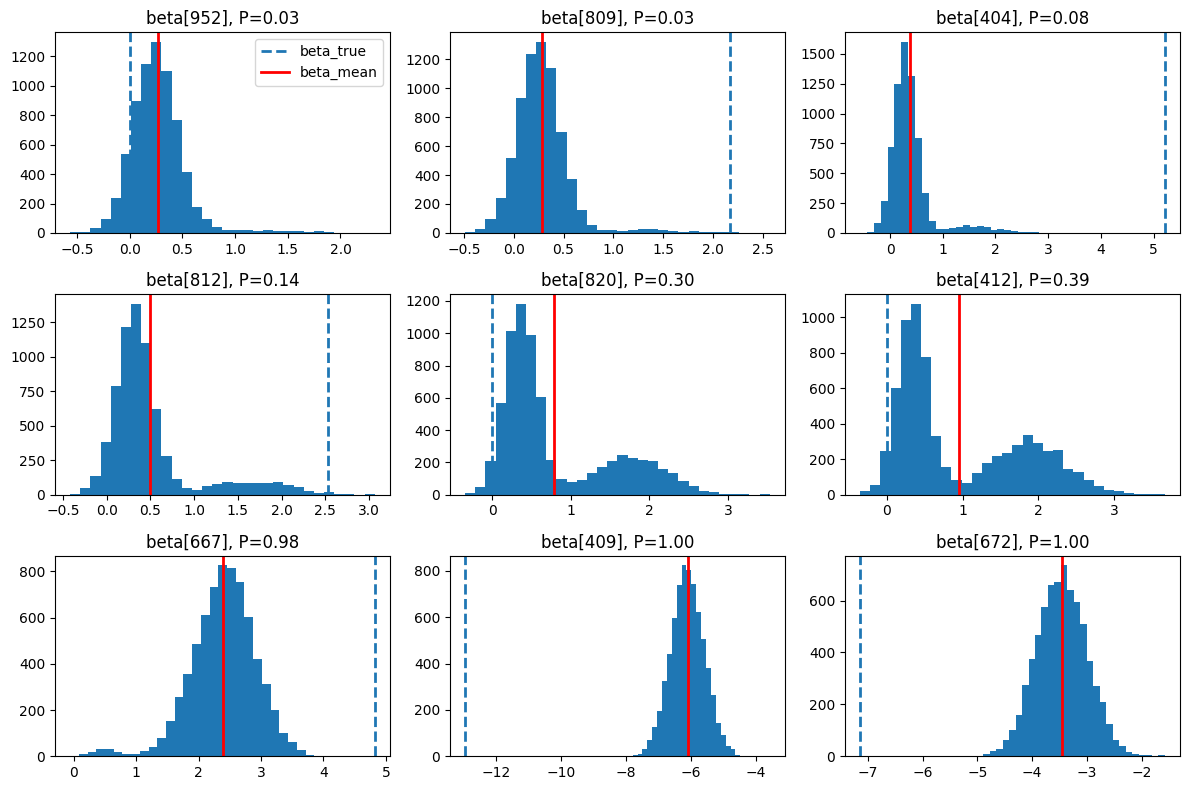

In [87]:
import matplotlib.pyplot as plt

gamma_prob = gibbs_results["gamma"].mean(axis=0)

beta_mean = gibbs_results["beta"].mean(axis=0)

top = np.argsort(gamma_prob)[-9:]

plt.figure(figsize=(12, 8))

for k, j in enumerate(top):
    plt.subplot(3, 3, k+1)

    plt.hist(
        gibbs_results["beta"][:, j],
        bins=30
    )

    plt.axvline(
        beta_true[j],
        linestyle="--",
        linewidth=2,
        label="beta_true"
    )

    plt.axvline(
        beta_mean[j],
        linestyle="-",
        linewidth=2,
        label="beta_mean",
        color = "red"
    )

    plt.title(f"beta[{j}], P={gamma_prob[j]:.2f}")

    if k == 0:
        plt.legend()

plt.tight_layout()
plt.show()

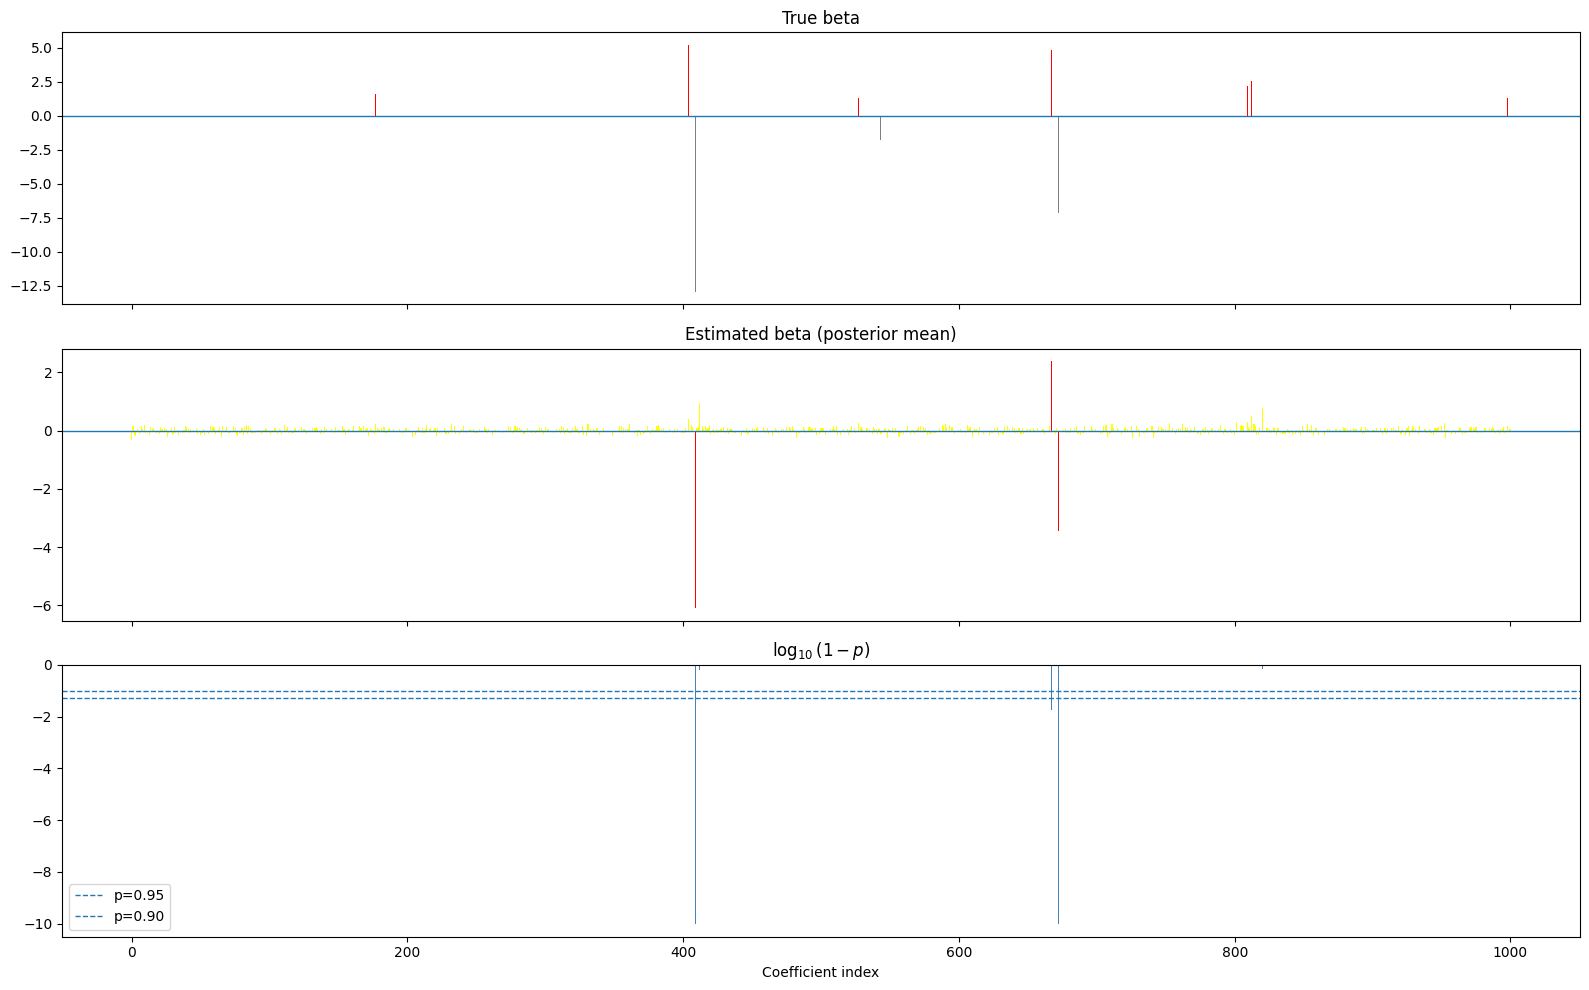

In [88]:
import numpy as np
import matplotlib.pyplot as plt

beta_mean = gibbs_results["beta"].mean(axis=0)
p_select = gibbs_results["gamma"].mean(axis=0)

idx = np.arange(len(beta_true))

fig, axes = plt.subplots(
    3, 1,
    figsize=(16, 10),
    sharex=True
)

# 1) beta true
colors_true = np.where(beta_true > 0, "red", "gray")

axes[0].bar(
    idx,
    beta_true,
    color=colors_true
)

axes[0].axhline(0, linewidth=1)
axes[0].set_title("True beta")


# 2) beta estimated
colors_est = np.where(
    p_select >= 0.95,
    "red",
    np.where(
        p_select >= 0.9,
        "orange",
        "yellow"
    )
)

axes[1].bar(
    idx,
    beta_mean,
    color=colors_est
)

axes[1].axhline(0, linewidth=1)
axes[1].set_title("Estimated beta (posterior mean)")


# 3) log10(1-p)
log_prob = np.log10(1 - p_select + 1e-10)

axes[2].bar(
    idx,
    log_prob,
    color="steelblue"
)

axes[2].set_title(r"$\log_{10}(1-p)$")
axes[2].axhline(
    np.log10(1-0.95),
    linestyle="--",
    linewidth=1,
    label="p=0.95"
)

axes[2].axhline(
    np.log10(1-0.9),
    linestyle="--",
    linewidth=1,
    label="p=0.90"
)

axes[2].legend()

axes[2].set_xlabel("Coefficient index")

plt.tight_layout()
plt.show()

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def evaluate_signals(X, beta_true, p_select, threshold=0.95, corr_threshold=0.9):

    true_signal = np.where(beta_true != 0)[0]
    selected = np.where(p_select >= threshold)[0]

    corr = np.corrcoef(X, rowvar=False)

    exact = []
    correlated = []
    missed = []

    false_positive = []

    for j in true_signal:

        if j in selected:
            exact.append(j)

        else:
            correlated_vars = np.where(
                (np.abs(corr[j, :]) > corr_threshold)
                &
                (np.arange(len(beta_true)) != j)
                &
                np.isin(np.arange(len(beta_true)), selected)
            )[0]

            if len(correlated_vars) > 0:
                correlated.append(
                    (j, correlated_vars.tolist())
                )
            else:
                missed.append(j)


    for j in selected:

        if beta_true[j] == 0:

            related = np.where(
                (np.abs(corr[j, true_signal]) > corr_threshold)
            )[0]

            if len(related) == 0:
                false_positive.append(j)


    summary = {
        "true_signals": len(true_signal),
        "selected": len(selected),
        "exact_detected": len(exact),
        "detected_by_correlated_feature": len(correlated),
        "missed": len(missed),
        "false_positive": len(false_positive)
    }


    return {
        "summary": summary,
        "exact": exact,
        "correlated": correlated,
        "missed": missed,
        "false_positive": false_positive,
        "p_select": p_select,
        "beta_true": beta_true,
        "beta_mean": beta_mean
    }


results = evaluate_signals(
    X,
    beta_true,
    p_select
)


pd.Series(results["summary"])

true_signals                      11
selected                           3
exact_detected                     3
detected_by_correlated_feature     0
missed                             8
false_positive                     0
dtype: int64

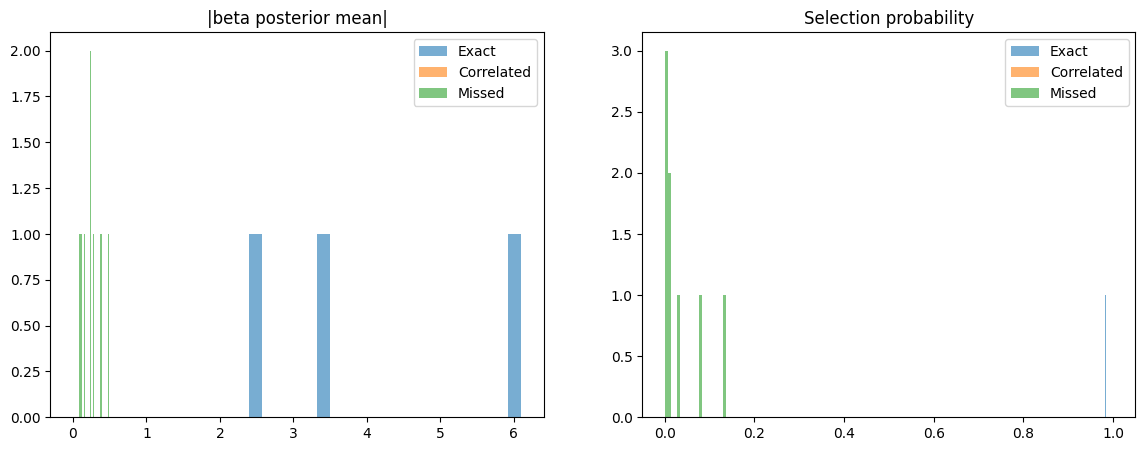

In [90]:
exact_idx = results["exact"]

corr_idx = [
    x[0] for x in results["correlated"]
]

missed_idx = results["missed"]


fig, axes = plt.subplots(
    1, 2,
    figsize=(14,5)
)


groups = {
    "Exact": exact_idx,
    "Correlated": corr_idx,
    "Missed": missed_idx
}


for name, idx in groups.items():

    axes[0].hist(
        np.abs(beta_mean[idx]),
        bins=20,
        alpha=0.6,
        label=name
    )

axes[0].set_title("|beta posterior mean|")
axes[0].legend()


for name, idx in groups.items():

    axes[1].hist(
        p_select[idx],
        bins=20,
        alpha=0.6,
        label=name
    )

axes[1].set_title("Selection probability")
axes[1].legend()


plt.show()